In [8]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import os

class BreakHisDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = []
        valid_ext = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')

        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(valid_ext):
                    self.image_paths.append(os.path.join(root, file))

        print(f"[INFO] Total BreaKHis images found: {len(self.image_paths)}")

        if len(self.image_paths) == 0:
            raise RuntimeError("No images found — check root_dir")

        self.transform = transforms.Compose([
            transforms.Resize((96, 96)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img)


In [7]:
import os

print(os.listdir("/kaggle/input"))
print(os.listdir("/kaggle/input/breakhis"))
print(os.listdir("/kaggle/input/breakhis/BreaKHis_v1/histology_slides/breast"))


['breakhis']
['BreaKHis_v1']
['README.txt', 'benign', 'count_files.sh', 'malignant']


In [9]:
from torch.utils.data import DataLoader

dataset = BreakHisDataset(
    root_dir="/kaggle/input/breakhis/BreaKHis_v1"
)

print("Dataset size:", len(dataset))

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    drop_last=True
)


[INFO] Total BreaKHis images found: 7909
Dataset size: 7909


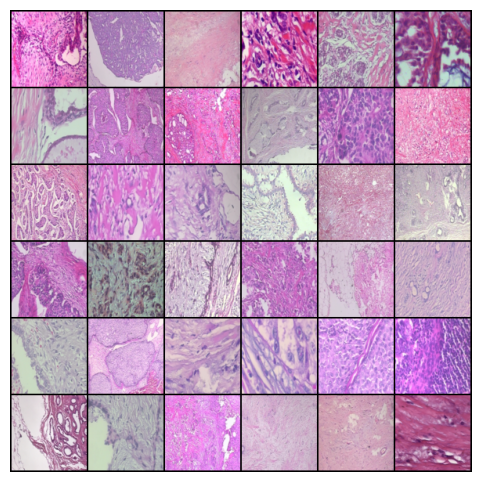

In [10]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

batch = next(iter(dataloader))

plt.figure(figsize=(6,6))
plt.axis("off")
plt.imshow(
    vutils.make_grid(batch[:36], nrow=6, normalize=True).permute(1,2,0)
)
plt.show()


In [11]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 6, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)


In [12]:
class Discriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8, 1, 6, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)


In [13]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()

optimizerD = torch.optim.Adam(netD.parameters(), lr=1e-4, betas=(0.5, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=1e-4, betas=(0.5, 0.999))

nz = 100


In [14]:
num_epochs = 60
print_interval = 200

for epoch in range(num_epochs):
    for batch_idx, real in enumerate(dataloader):
        real = real.to(device)
        b_size = real.size(0)

        # ---- Train Discriminator ----
        netD.zero_grad()
        label_real = torch.ones(b_size, device=device)
        output = netD(real)
        errD_real = criterion(output, label_real)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label_fake = torch.zeros(b_size, device=device)
        output = netD(fake.detach())
        errD_fake = criterion(output, label_fake)

        errD = errD_real + errD_fake
        errD.backward()
        optimizerD.step()

        # ---- Train Generator ----
        netG.zero_grad()
        label_gen = torch.ones(b_size, device=device)
        output = netD(fake)
        errG = criterion(output, label_gen)
        errG.backward()
        optimizerG.step()

        # ---- Print every 200 batches ----
        if (batch_idx + 1) % print_interval == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"Batch [{batch_idx+1}/{len(dataloader)}] "
                f"Loss_D: {errD.item():.4f} "
                f"Loss_G: {errG.item():.4f}"
            )

    # ---- Epoch summary ----
    print(
        f"Epoch [{epoch+1}/{num_epochs}] completed | "
        f"Last Loss_D: {errD.item():.4f} "
        f"Last Loss_G: {errG.item():.4f}"
    )


Epoch [1/60] completed | Last Loss_D: 0.0024 Last Loss_G: 19.1633
Epoch [2/60] completed | Last Loss_D: 0.3220 Last Loss_G: 3.1539
Epoch [3/60] completed | Last Loss_D: 0.1532 Last Loss_G: 4.4005
Epoch [4/60] completed | Last Loss_D: 0.3426 Last Loss_G: 4.9698
Epoch [5/60] completed | Last Loss_D: 0.2517 Last Loss_G: 3.4206
Epoch [6/60] completed | Last Loss_D: 0.4076 Last Loss_G: 5.1644
Epoch [7/60] completed | Last Loss_D: 0.6238 Last Loss_G: 5.0778
Epoch [8/60] completed | Last Loss_D: 0.4175 Last Loss_G: 2.9512
Epoch [9/60] completed | Last Loss_D: 1.0322 Last Loss_G: 5.9416
Epoch [10/60] completed | Last Loss_D: 0.5030 Last Loss_G: 3.6323
Epoch [11/60] completed | Last Loss_D: 0.5256 Last Loss_G: 2.5838
Epoch [12/60] completed | Last Loss_D: 1.8560 Last Loss_G: 7.0991
Epoch [13/60] completed | Last Loss_D: 0.8896 Last Loss_G: 9.3527
Epoch [14/60] completed | Last Loss_D: 0.2697 Last Loss_G: 2.2981
Epoch [15/60] completed | Last Loss_D: 0.4960 Last Loss_G: 3.0664
Epoch [16/60] comp

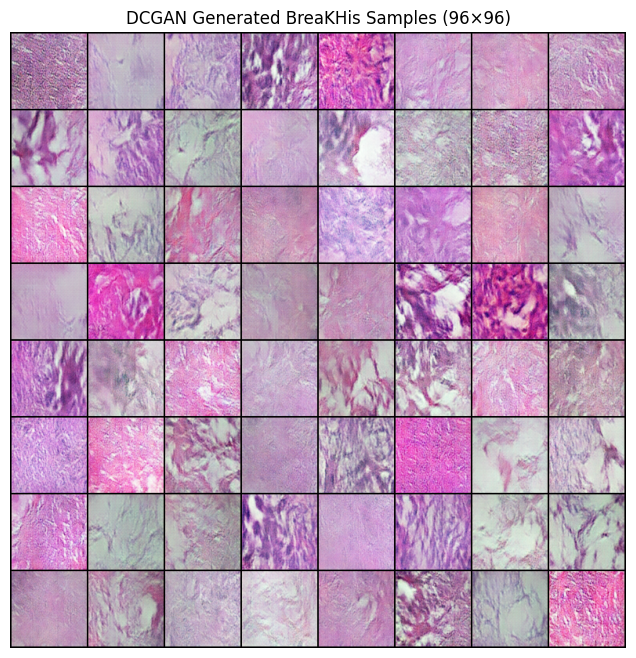

In [15]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt

netG.eval()
fixed_noise = torch.randn(64, 100, 1, 1, device=device)

with torch.no_grad():
    fake = netG(fixed_noise).cpu()

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("DCGAN Generated BreaKHis Samples (96×96)")
plt.imshow(
    vutils.make_grid(fake, padding=2, normalize=True).permute(1,2,0)
)
plt.show()


In [16]:
real_images = []
for imgs in dataloader:
    real_images.append(imgs)
    if len(real_images)*imgs.size(0) >= 1000:
        break

real_images = torch.cat(real_images, dim=0)[:1000]


In [17]:
def generate_fake(netG, n=1000):
    netG.eval()
    fake_imgs = []
    with torch.no_grad():
        for _ in range(n // 64):
            z = torch.randn(64, 100, 1, 1, device=device)
            fake_imgs.append(netG(z).cpu())
    return torch.cat(fake_imgs, dim=0)

fake_images = generate_fake(netG, 1000)


In [18]:
from torchvision.models import inception_v3
import torch.nn.functional as F
import numpy as np
from scipy.linalg import sqrtm


In [19]:
inception = inception_v3(pretrained=True).to(device)
inception.fc = torch.nn.Identity()
inception.eval()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 203MB/s] 


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [20]:
def get_inception_features(images):
    feats = []
    with torch.no_grad():
        for i in range(0, len(images), 32):
            batch = images[i:i+32].to(device)
            batch = F.interpolate(batch, size=299, mode='bilinear')
            feats.append(inception(batch).cpu())
    return torch.cat(feats).numpy()


In [21]:
real_feats = get_inception_features(real_images)
fake_feats = get_inception_features(fake_images)


In [22]:
def fid_score(r, f):
    mu_r, mu_f = r.mean(0), f.mean(0)
    cov_r, cov_f = np.cov(r, rowvar=False), np.cov(f, rowvar=False)
    covmean = sqrtm(cov_r @ cov_f)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return np.sum((mu_r - mu_f)**2) + np.trace(cov_r + cov_f - 2*covmean)


In [23]:
fid = fid_score(real_feats, fake_feats)
print("FID:", fid)


FID: 85.88546363519848


In [24]:
from skimage.metrics import structural_similarity as ssim


In [25]:
def compute_ssim(real, fake):
    scores = []
    for i in range(100):
        r = real[i].permute(1,2,0).numpy()
        f = fake[i].permute(1,2,0).numpy()
        scores.append(
            ssim(r, f, channel_axis=2, data_range=2)
        )
    return np.mean(scores)


In [26]:
ssim_score = compute_ssim(real_images, fake_images)
print("SSIM:", ssim_score)


SSIM: 0.14812876


In [27]:
def compute_mmd(x, y, sigma=1.0):
    xx = torch.mm(x, x.t())
    yy = torch.mm(y, y.t())
    xy = torch.mm(x, y.t())

    rx = xx.diag().unsqueeze(0)
    ry = yy.diag().unsqueeze(0)

    Kxx = torch.exp(-(rx.t() + rx - 2*xx) / (2*sigma))
    Kyy = torch.exp(-(ry.t() + ry - 2*yy) / (2*sigma))
    Kxy = torch.exp(-(rx.t() + ry - 2*xy) / (2*sigma))

    return Kxx.mean() + Kyy.mean() - 2*Kxy.mean()


In [28]:
mmd = compute_mmd(
    torch.tensor(real_feats[:200]),
    torch.tensor(fake_feats[:200])
)
print("MMD:", mmd.item())


MMD: 0.009999999776482582


In [29]:
torch.save(netG.state_dict(), "dcgan_breakhis_generator.pth")
torch.save(netD.state_dict(), "dcgan_breakhis_discriminator.pth")


In [30]:
# ===================== FINAL METRICS SUMMARY ===================== #

print("\n" + "="*60)
print("FINAL GAN EVALUATION METRICS")
print("="*60)

# ---- FID ----
# FID has no fixed maximum; lower is better, 0 is ideal
print("FID:", fid)

# ---- SSIM ----
# SSIM ranges from 0 to 1
print("SSIM:", ssim_score)

# ---- MMD ----
# MMD has no fixed maximum; 0 is ideal
print("MMD:", mmd.item())

print("="*60)



FINAL GAN EVALUATION METRICS
FID: 85.88546363519848
SSIM: 0.14812876
MMD: 0.009999999776482582
